# 01. 데이터 탐색 및 시각화 (EDA)

이 노트북에서 할 것:
1. WAV 파일 읽기 & 파형 시각화
2. Mel Spectrogram 변환 & 시각화
3. 여러 화자 비교
4. 시간 잘랐을 때(0.5s, 1s, 1.5s) Mel Spectrogram 비교
5. 데이터셋 전체 통계 (화자별 샘플 수, 발화 길이 분포)

## 1. 라이브러리 불러오기

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import librosa.display

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print('라이브러리 로드 완료')

라이브러리 로드 완료


## 2. 경로 설정

In [2]:
# 프로젝트 루트 경로
ROOT = r'C:\Users\최세영\Desktop\Project\early-speaker-recognition\New_Sample'

WAV_ROOT  = os.path.join(ROOT, '원천데이터',  'TS_common_01')
JSON_ROOT = os.path.join(ROOT, '라벨링데이터', 'TL_common_01')

# 샘플로 사용할 화자 3명 (날짜/화자ID)
SAMPLE_SPEAKERS = [
    ('2021-12-16', '0047'),
    ('2021-12-16', '0134'),
    ('2021-12-16', '0936'),
]

print('경로 설정 완료')
print(f'WAV  경로: {WAV_ROOT}')
print(f'JSON 경로: {JSON_ROOT}')

경로 설정 완료
WAV  경로: C:\Users\최세영\Desktop\Project\early-speaker-recognition\New_Sample\원천데이터\TS_common_01
JSON 경로: C:\Users\최세영\Desktop\Project\early-speaker-recognition\New_Sample\라벨링데이터\TL_common_01


## 3. 헬퍼 함수

In [3]:
def load_wav_and_json(date, speaker_id, file_index=0):
    """
    특정 화자의 file_index번째 파일을 읽어서 반환합니다.
    
    Returns:
        wav (np.array): 파형 데이터
        sr  (int)     : 샘플링 레이트 (16000)
        meta (dict)   : JSON 메타데이터
    """
    wav_dir  = os.path.join(WAV_ROOT,  date, speaker_id)
    json_dir = os.path.join(JSON_ROOT, date, speaker_id)

    wav_files  = sorted(os.listdir(wav_dir))
    json_files = sorted(os.listdir(json_dir))

    wav_path  = os.path.join(wav_dir,  wav_files[file_index])
    json_path = os.path.join(json_dir, json_files[file_index])

    # WAV 읽기 (sr=None → 원본 샘플링레이트 유지)
    wav, sr = librosa.load(wav_path, sr=None)

    with open(json_path, 'r', encoding='utf-8') as f:
        meta = json.load(f)

    return wav, sr, meta


def get_mel(wav, sr, n_mels=80, n_fft=400, hop_length=160):
    """
    WAV → Mel Spectrogram 변환
    
    파라미터 설명:
        n_mels=80     : Mel 필터 개수 (주파수 해상도)
        n_fft=400     : STFT 창 크기 → 400/16000 = 25ms
        hop_length=160: STFT 이동 크기 → 160/16000 = 10ms
    
    Returns:
        mel_db (np.array): (n_mels, 시간프레임) shape의 dB 스케일 Mel Spectrogram
    """
    mel = librosa.feature.melspectrogram(
        y=wav, sr=sr,
        n_mels=n_mels,
        n_fft=n_fft,
        hop_length=hop_length,
        fmin=20,    # 사람 가청 주파수 하한
        fmax=8000   # 16kHz 오디오의 최대 유효 주파수
    )
    # 에너지 → dB 변환 (로그 스케일, 사람 청각과 더 비슷)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db


def trim_wav(wav, sr, speech_start, duration):
    """
    speech_start 기준으로 duration초만큼 자르기
    
    예) speech_start=0.4, duration=1.0 → 0.4초~1.4초 구간 반환
    """
    start_sample = int(speech_start * sr)
    end_sample   = start_sample + int(duration * sr)
    # 오디오 길이를 넘으면 있는 만큼만
    end_sample = min(end_sample, len(wav))
    return wav[start_sample:end_sample]


print('헬퍼 함수 정의 완료')

헬퍼 함수 정의 완료


## 4. 파형(Waveform) 시각화

WAV 파일을 읽으면 어떻게 생겼는지 먼저 확인합니다.

In [4]:
# 화자 0047의 첫 번째 파일 로드
wav, sr, meta = load_wav_and_json('2021-12-16', '0047', file_index=0)

speech_start = float(meta['Other']['SpeechStart'])
speech_end   = float(meta['Other']['SpeechEnd'])
transcription = meta['Transcription']['LabelText']
speaker_info  = meta['Speaker']

print('=== 파일 정보 ===')
print(f'파일 길이     : {len(wav)/sr:.2f}초 ({len(wav):,} 샘플)')
print(f'샘플링레이트  : {sr} Hz')
print(f'SpeechStart   : {speech_start}초')
print(f'SpeechEnd     : {speech_end}초')
print(f'실제 발화 길이: {speech_end - speech_start:.2f}초')
print(f'전사 텍스트   : {transcription}')
print(f'화자 성별     : {speaker_info["Gender"]}')
print(f'화자 나이대   : {speaker_info["Age"]}')

=== 파일 정보 ===
파일 길이     : 3.07초 (49,120 샘플)
샘플링레이트  : 16000 Hz
SpeechStart   : 0.4초
SpeechEnd     : 2.57초
실제 발화 길이: 2.17초
전사 텍스트   : 에어컨 최대 강풍으로 틀어 줘.
화자 성별     : Female
화자 나이대   : 20~59


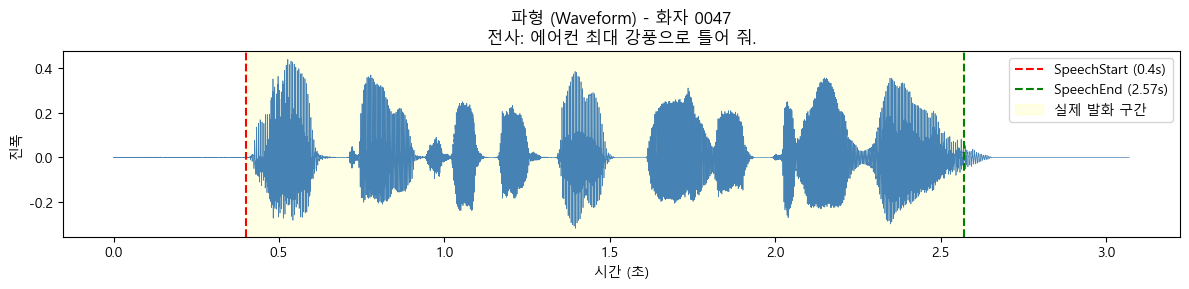


[해석] 빨간선 이전/초록선 이후는 무음 구간입니다.
       실제 학습에는 노란 구간(SpeechStart~SpeechEnd)만 사용합니다.


In [5]:
fig, ax = plt.subplots(figsize=(12, 3))

# 시간 축 (초 단위)
time_axis = np.arange(len(wav)) / sr

ax.plot(time_axis, wav, color='steelblue', linewidth=0.5)

# SpeechStart / SpeechEnd 표시
ax.axvline(x=speech_start, color='red',   linestyle='--', label=f'SpeechStart ({speech_start}s)')
ax.axvline(x=speech_end,   color='green', linestyle='--', label=f'SpeechEnd ({speech_end}s)')
ax.axvspan(speech_start, speech_end, alpha=0.1, color='yellow', label='실제 발화 구간')

ax.set_xlabel('시간 (초)')
ax.set_ylabel('진폭')
ax.set_title(f'파형 (Waveform) - 화자 0047\n전사: {transcription}')
ax.legend()
plt.tight_layout()
plt.show()

print('\n[해석] 빨간선 이전/초록선 이후는 무음 구간입니다.')
print('       실제 학습에는 노란 구간(SpeechStart~SpeechEnd)만 사용합니다.')

## 5. Mel Spectrogram 시각화

파형을 시간-주파수 2D 이미지로 변환합니다.

In [6]:
# SpeechStart~SpeechEnd 구간만 잘라서 Mel 변환
start_sample = int(speech_start * sr)
end_sample   = int(speech_end * sr)
wav_trimmed  = wav[start_sample:end_sample]

mel_db = get_mel(wav_trimmed, sr)

print(f'Mel Spectrogram shape: {mel_db.shape}')
print(f'  → ({mel_db.shape[0]} Mel 필터, {mel_db.shape[1]} 시간 프레임)')
print(f'  → 1 프레임 = 10ms → 총 {mel_db.shape[1] * 10}ms')

Mel Spectrogram shape: (80, 218)
  → (80 Mel 필터, 218 시간 프레임)
  → 1 프레임 = 10ms → 총 2180ms


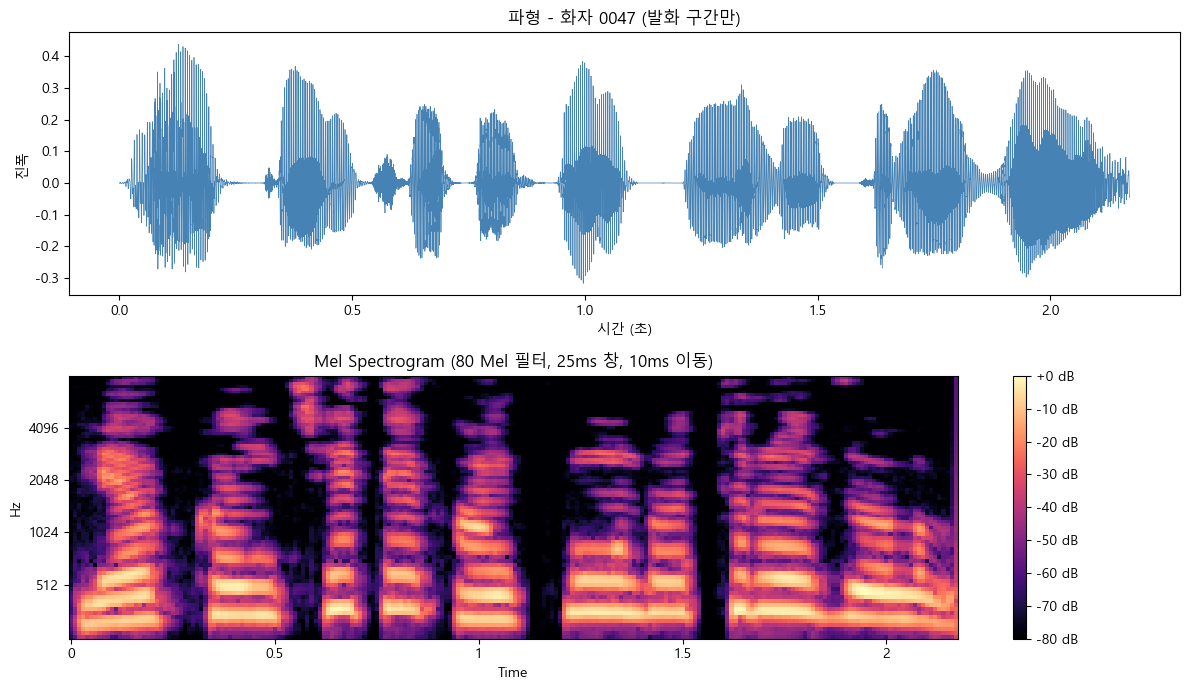


[해석]
  - X축: 시간
  - Y축: 주파수 (아래=저음, 위=고음)
  - 색상: 밝을수록 에너지가 강함
  - 화자마다 에너지 분포 패턴이 다름 → 모델이 이걸 구분함


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# 위: 파형
time_axis = np.arange(len(wav_trimmed)) / sr
axes[0].plot(time_axis, wav_trimmed, color='steelblue', linewidth=0.5)
axes[0].set_xlabel('시간 (초)')
axes[0].set_ylabel('진폭')
axes[0].set_title(f'파형 - 화자 0047 (발화 구간만)')

# 아래: Mel Spectrogram
img = librosa.display.specshow(
    mel_db,
    sr=sr,
    hop_length=160,
    x_axis='time',
    y_axis='mel',
    fmin=20,
    fmax=8000,
    ax=axes[1],
    cmap='magma'
)
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
axes[1].set_title('Mel Spectrogram (80 Mel 필터, 25ms 창, 10ms 이동)')

plt.tight_layout()
plt.show()

print('\n[해석]')
print('  - X축: 시간')
print('  - Y축: 주파수 (아래=저음, 위=고음)')
print('  - 색상: 밝을수록 에너지가 강함')
print('  - 화자마다 에너지 분포 패턴이 다름 → 모델이 이걸 구분함')

## 6. 화자 3명 비교

같은 파라미터로 다른 화자의 Mel Spectrogram을 비교합니다.

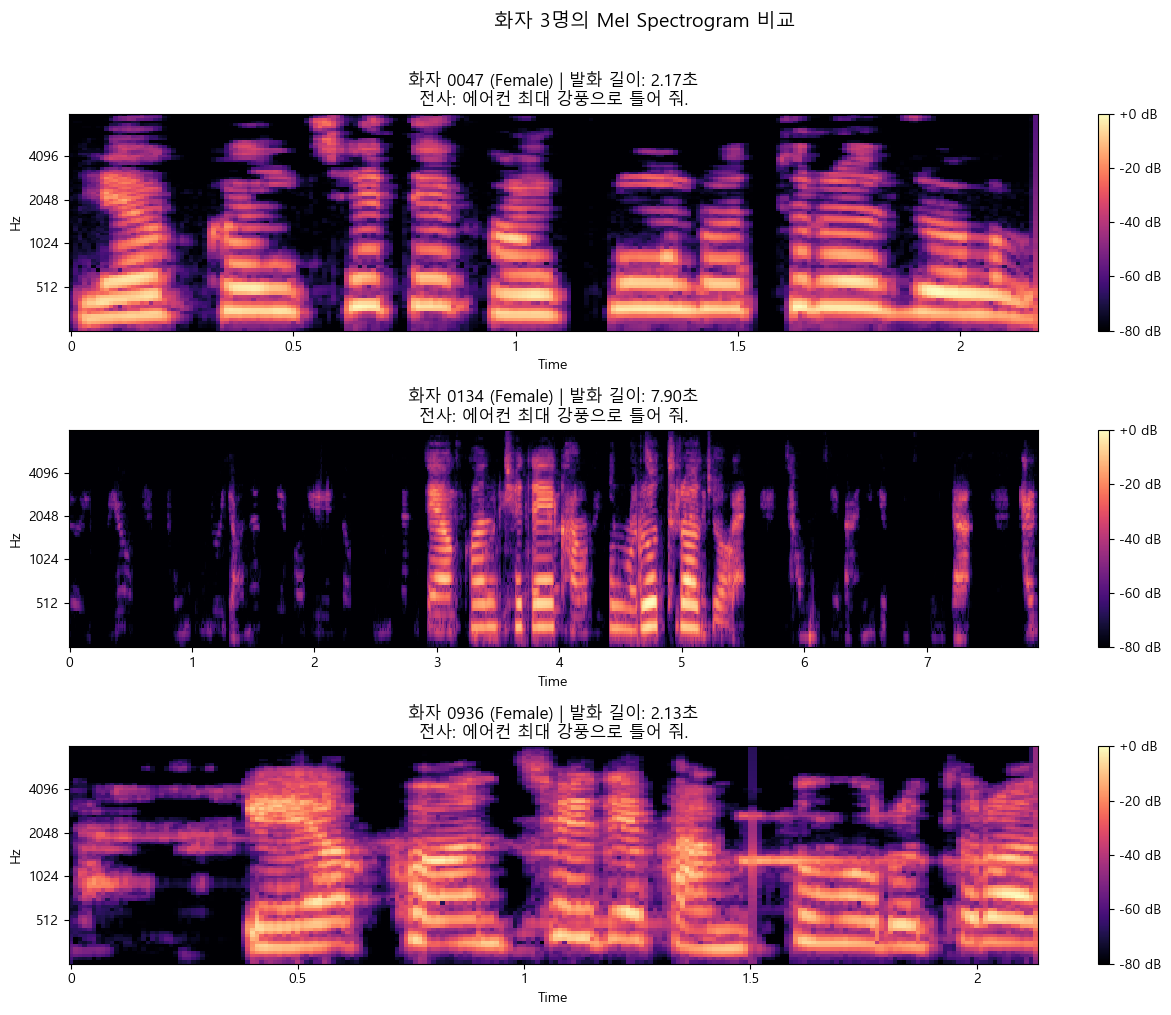


[관찰 포인트]
  - 에너지가 집중된 주파수 대역이 화자마다 다른가?
  - 전체적인 패턴(밝고 어두운 세로 줄기)이 차이가 있는가?


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10))

for i, (date, spk_id) in enumerate(SAMPLE_SPEAKERS):
    wav, sr, meta = load_wav_and_json(date, spk_id, file_index=0)

    s_start = float(meta['Other']['SpeechStart'])
    s_end   = float(meta['Other']['SpeechEnd'])
    text    = meta['Transcription']['LabelText']
    gender  = meta['Speaker']['Gender']

    wav_trimmed = wav[int(s_start*sr):int(s_end*sr)]
    mel_db = get_mel(wav_trimmed, sr)

    img = librosa.display.specshow(
        mel_db, sr=sr, hop_length=160,
        x_axis='time', y_axis='mel',
        fmin=20, fmax=8000,
        ax=axes[i], cmap='magma'
    )
    fig.colorbar(img, ax=axes[i], format='%+2.0f dB')
    axes[i].set_title(
        f'화자 {spk_id} ({gender}) | 발화 길이: {s_end-s_start:.2f}초\n전사: {text}'
    )

plt.suptitle('화자 3명의 Mel Spectrogram 비교', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\n[관찰 포인트]')
print('  - 에너지가 집중된 주파수 대역이 화자마다 다른가?')
print('  - 전체적인 패턴(밝고 어두운 세로 줄기)이 차이가 있는가?')

## 7. 핵심 실험: 시간을 잘랐을 때 Mel Spectrogram 비교

이 프로젝트의 핵심! 0.5초 / 1.0초 / 1.5초 / 전체 비교

전사: 오늘은 커피 안 마실 거야.
전체 발화 길이: 3.41초


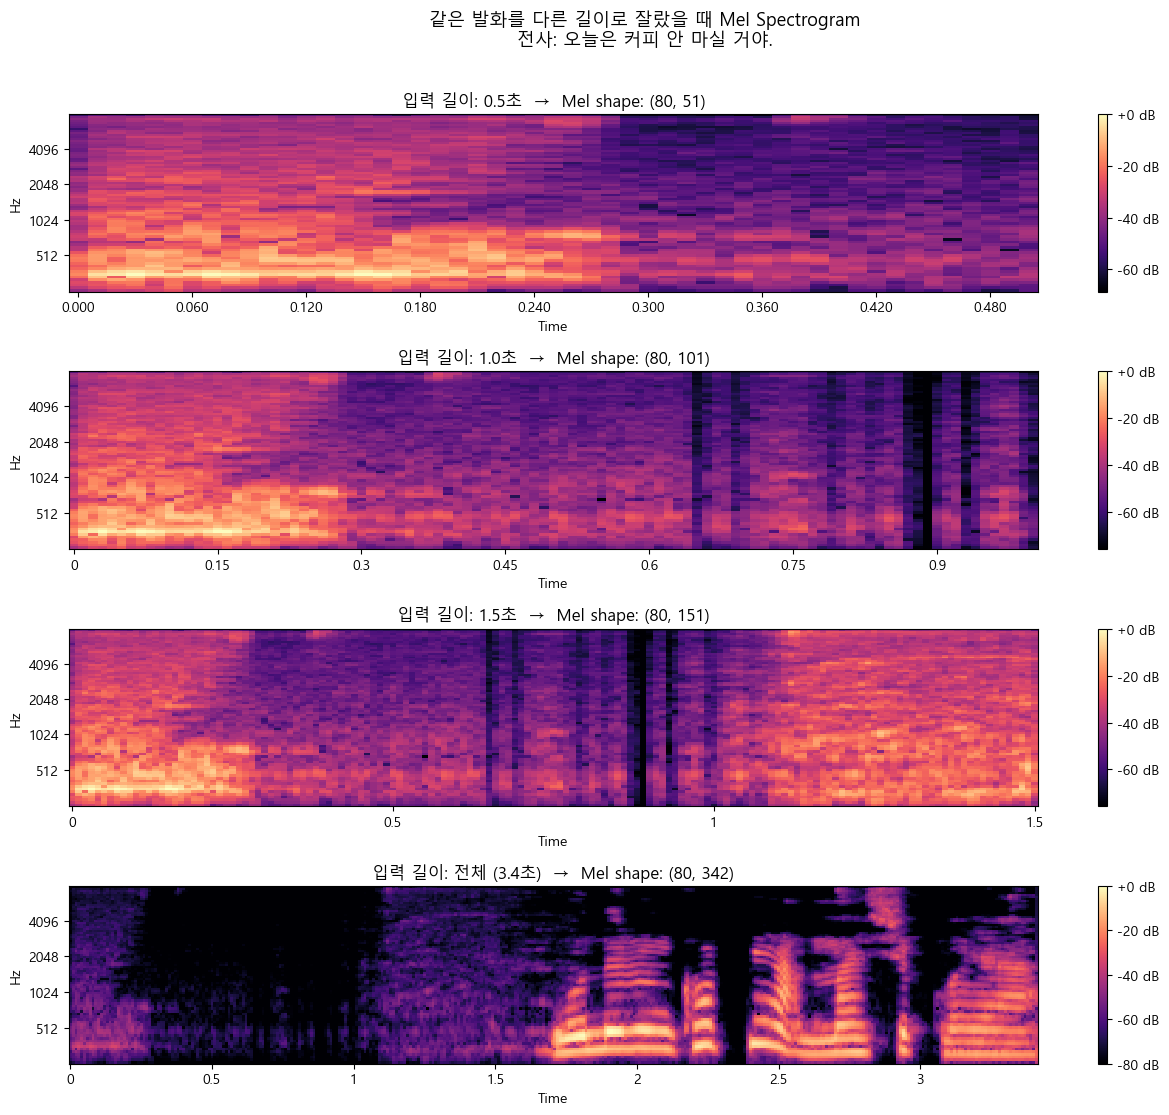


[핵심 관찰]
  - 짧을수록 Mel Spectrogram의 시간 축이 줄어듦
  - 0.5초에서도 어느 정도 패턴이 보이는가?
  - 이 패턴만으로 화자를 구분할 수 있을까?  → 실험의 목표!


In [9]:
wav, sr, meta = load_wav_and_json('2021-12-16', '0047', file_index=2)

speech_start = float(meta['Other']['SpeechStart'])
speech_end   = float(meta['Other']['SpeechEnd'])
full_duration = speech_end - speech_start
text = meta['Transcription']['LabelText']

print(f'전사: {text}')
print(f'전체 발화 길이: {full_duration:.2f}초')

durations = [0.5, 1.0, 1.5, full_duration]
labels    = ['0.5초', '1.0초', '1.5초', f'전체 ({full_duration:.1f}초)']

fig, axes = plt.subplots(len(durations), 1, figsize=(13, 11))

for i, (dur, label) in enumerate(zip(durations, labels)):
    if dur > full_duration:
        dur = full_duration  # 발화보다 길면 전체 사용

    wav_cut = trim_wav(wav, sr, speech_start, dur)
    mel_db  = get_mel(wav_cut, sr)

    img = librosa.display.specshow(
        mel_db, sr=sr, hop_length=160,
        x_axis='time', y_axis='mel',
        fmin=20, fmax=8000,
        ax=axes[i], cmap='magma'
    )
    fig.colorbar(img, ax=axes[i], format='%+2.0f dB')
    axes[i].set_title(f'입력 길이: {label}  →  Mel shape: {mel_db.shape}')

plt.suptitle(f'같은 발화를 다른 길이로 잘랐을 때 Mel Spectrogram\n전사: {text}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('\n[핵심 관찰]')
print('  - 짧을수록 Mel Spectrogram의 시간 축이 줄어듦')
print('  - 0.5초에서도 어느 정도 패턴이 보이는가?')
print('  - 이 패턴만으로 화자를 구분할 수 있을까?  → 실험의 목표!')

## 8. 데이터셋 전체 통계

모델 학습 전에 반드시 확인해야 할 수치들

In [10]:
import pandas as pd
from pathlib import Path

records = []

json_root = Path(JSON_ROOT)
for json_path in sorted(json_root.rglob('*.json')):
    with open(json_path, 'r', encoding='utf-8') as f:
        meta = json.load(f)

    parts = json_path.parts
    date       = parts[-3]   # 2021-12-16 등
    speaker_id = parts[-2]   # 0047 등

    s_start = float(meta['Other']['SpeechStart'])
    s_end   = float(meta['Other']['SpeechEnd'])
    duration = s_end - s_start

    records.append({
        'date'      : date,
        'speaker_id': speaker_id,
        'gender'    : meta['Speaker']['Gender'],
        'age'       : meta['Speaker']['Age'],
        'speech_start'  : s_start,
        'speech_end'    : s_end,
        'speech_duration': duration,
        'file_length': float(meta['File']['FileLength']),
        'quality'   : meta['Other']['QualityStatus'],
        'file_name' : meta['File']['FileName'],
    })

df = pd.DataFrame(records)
print(f'총 파일 수  : {len(df):,}')
print(f'총 화자 수  : {df["speaker_id"].nunique()}')
print()
print(df.head(5))

총 파일 수  : 4,835
총 화자 수  : 50

         date speaker_id  gender    age  speech_start  speech_end  \
0  2021-12-16       0047  Female  20~59           0.4        2.57   
1  2021-12-16       0047  Female  20~59           0.4        4.86   
2  2021-12-16       0047  Female  20~59           0.4        3.81   
3  2021-12-16       0047  Female  20~59           0.4        3.65   
4  2021-12-16       0047  Female  20~59           0.4        3.00   

   speech_duration  file_length quality                              file_name  
0             2.17         3.07    Good  B0001-0047F1111-106001_0-00018869.wav  
1             4.46         5.36    Good  B0002-0047F1111-106001_0-00018881.wav  
2             3.41         4.31    Good  B0003-0047F1111-106001_0-00018892.wav  
3             3.25         4.15    Good  B0004-0047F1111-106001_0-00018968.wav  
4             2.60         3.50    Good  B0005-0047F1111-106001_0-00019005.wav  


In [11]:
# 화자별 샘플 수
spk_counts = df.groupby('speaker_id').size().sort_values(ascending=False)
print('=== 화자별 샘플 수 ===')
print(spk_counts.describe())
print()
print(spk_counts)

=== 화자별 샘플 수 ===
count     50.00000
mean      96.70000
std       53.11568
min        1.00000
25%       36.50000
50%      137.00000
75%      140.00000
max      140.00000
dtype: float64

speaker_id
0047    140
0275    140
0857    140
0601    140
0756    140
0659    140
1574    140
1323    140
2636    140
2620    140
1653    140
1756    140
1901    140
2052    140
1315    140
1262    140
1001    139
0936    139
0134    139
0375    139
2097    139
1836    138
1461    138
0438    137
0631    137
0195    137
1401    132
0862    130
0719    125
0301    106
1017    100
2344     94
2439     67
2363     64
2513     47
2468     45
2399     38
2572     36
2247     33
2321     32
1303     31
0121     27
2335     22
1591     19
2096     18
2415     16
2367     15
2205     12
2594      3
2057      1
dtype: int64


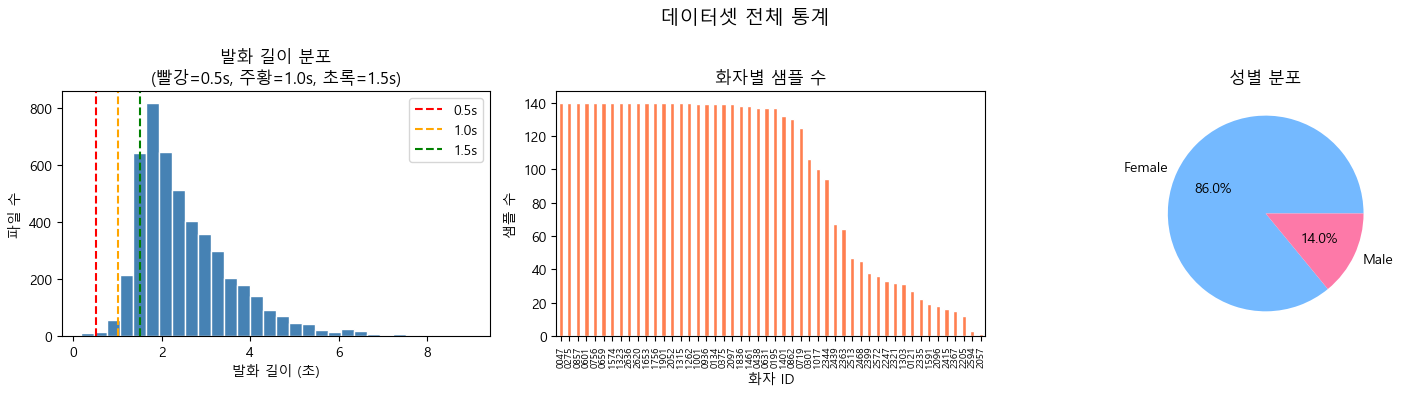

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. 발화 길이 분포
axes[0].hist(df['speech_duration'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(x=0.5, color='red',    linestyle='--', label='0.5s')
axes[0].axvline(x=1.0, color='orange', linestyle='--', label='1.0s')
axes[0].axvline(x=1.5, color='green',  linestyle='--', label='1.5s')
axes[0].set_xlabel('발화 길이 (초)')
axes[0].set_ylabel('파일 수')
axes[0].set_title('발화 길이 분포\n(빨강=0.5s, 주황=1.0s, 초록=1.5s)')
axes[0].legend()

# 2. 화자별 샘플 수
spk_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_xlabel('화자 ID')
axes[1].set_ylabel('샘플 수')
axes[1].set_title('화자별 샘플 수')
axes[1].tick_params(axis='x', rotation=90, labelsize=7)

# 3. 성별 분포
gender_counts = df['gender'].value_counts()
axes[2].pie(gender_counts.values, labels=gender_counts.index,
            autopct='%1.1f%%', colors=['#74b9ff', '#fd79a8'])
axes[2].set_title('성별 분포')

plt.suptitle('데이터셋 전체 통계', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# 발화 길이별 사용 가능한 샘플 비율 확인 (핵심!)
print('=== 발화 길이별 사용 가능한 샘플 수 ===')
print('(각 duration보다 긴 발화만 해당 실험에 사용 가능)')
print()

for dur in [0.5, 1.0, 1.5, 2.0]:
    usable = (df['speech_duration'] >= dur).sum()
    pct = usable / len(df) * 100
    print(f'  {dur}초 이상: {usable:4d}개 ({pct:.1f}%)')

print()
print(f'발화 길이 통계:')
print(df['speech_duration'].describe().round(3))

=== 발화 길이별 사용 가능한 샘플 수 ===
(각 duration보다 긴 발화만 해당 실험에 사용 가능)

  0.5초 이상: 4825개 (99.8%)
  1.0초 이상: 4777개 (98.8%)
  1.5초 이상: 4301개 (89.0%)
  2.0초 이상: 2940개 (60.8%)

발화 길이 통계:
count    4835.000
mean        2.514
std         1.082
min         0.170
25%         1.710
50%         2.230
75%         3.065
max         8.990
Name: speech_duration, dtype: float64


In [14]:
# 품질 필터 확인
print('=== 품질 상태 분포 ===')
print(df['quality'].value_counts())
print()
print('→ Good이 아닌 것은 학습에서 제외하는 것을 고려하세요.')

=== 품질 상태 분포 ===
quality
Good    4835
Name: count, dtype: int64

→ Good이 아닌 것은 학습에서 제외하는 것을 고려하세요.


## 9. 정리: 전처리에서 결정해야 할 것들

이 EDA를 통해 아래 질문들에 답할 수 있습니다:

In [15]:
min_dur = df['speech_duration'].min()
max_dur = df['speech_duration'].max()
mean_dur = df['speech_duration'].mean()

print('=== 전처리 설계를 위한 핵심 수치 ===')
print()
print(f'[발화 길이]')
print(f'  최소: {min_dur:.2f}초 → 0.5s 실험 시 이것보다 짧은 발화는 제외')
print(f'  최대: {max_dur:.2f}초')
print(f'  평균: {mean_dur:.2f}초')
print()
print(f'[화자 정보]')
print(f'  총 화자 수: {df["speaker_id"].nunique()}명')
print(f'  최소 샘플: {spk_counts.min()}개/화자 → train/test 분리 가능 여부')
print(f'  최대 샘플: {spk_counts.max()}개/화자')
print()
print('[다음 단계: preprocess.py 작성]')
print('  1. speech_duration >= 1.5초 인 파일만 사용 (or 0.5초도 포함)')
print('  2. SpeechStart 기준으로 0.5 / 1.0 / 1.5 / full 버전 잘라 저장')
print('  3. 각 화자에서 80% train / 20% test 분리')
print('  4. Mel Spectrogram으로 변환 후 .npy 또는 .pt 파일로 저장')

=== 전처리 설계를 위한 핵심 수치 ===

[발화 길이]
  최소: 0.17초 → 0.5s 실험 시 이것보다 짧은 발화는 제외
  최대: 8.99초
  평균: 2.51초

[화자 정보]
  총 화자 수: 50명
  최소 샘플: 1개/화자 → train/test 분리 가능 여부
  최대 샘플: 140개/화자

[다음 단계: preprocess.py 작성]
  1. speech_duration >= 1.5초 인 파일만 사용 (or 0.5초도 포함)
  2. SpeechStart 기준으로 0.5 / 1.0 / 1.5 / full 버전 잘라 저장
  3. 각 화자에서 80% train / 20% test 분리
  4. Mel Spectrogram으로 변환 후 .npy 또는 .pt 파일로 저장
